# Day 106 — Linear Regression Foundations
**Month 6 | Week 3 | ML Foundations | 80 Points + 10★ Bonus**

---

### Business Scenario
You are a **Data Analyst at ShopEase**.  
The Head of Revenue asks: **"Can we predict how much a customer will spend on their next order?"**

If you can predict order value, ShopEase can:
- Personalise discount thresholds (don't over-discount high spenders)
- Target low-predicted-value customers with upsell offers
- Forecast monthly revenue from pipeline

**Your job today:** Build a linear regression model that predicts `order_value` from customer + order features, evaluate how good it is, and explain the result to a non-technical stakeholder.

---

### Sections
| Section | Topic | Points |
|---------|-------|--------|
| **A** | Data Setup + EDA | 15 pts |
| **B** | Simple Linear Regression (1 feature) | 20 pts |
| **C** | Multiple Linear Regression | 25 pts |
| **D** | Model Evaluation + Residual Analysis | 10 pts |
| **E** | Business Interpretation (NRA) | 10 pts |
| **★ Bonus** | Feature importance + coefficient table | 10 pts |

**Total: 80 pts + 10★**

---

> ⚠️ **Rules:**
> 1. Run cells top-to-bottom before submitting.
> 2. `savefig()` before `plt.show()` — always.
> 3. Every written insight → NRA format (Number + Reason + Action).
> 4. Never modify the raw data cell.


---
## Section 1 — Raw Data (DO NOT MODIFY)

In [6]:
# ── RAW DATA — DO NOT MODIFY BELOW THIS CELL ────────────────────────────────
import numpy as np
import pandas as pd

np.random.seed(42)
n = 300

cities       = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad']
categories   = ['Electronics', 'Fashion', 'Home', 'Beauty', 'Sports']
segments     = ['Premium', 'Standard', 'Budget']
payments     = ['UPI', 'Card', 'COD', 'Netbanking']

city         = np.random.choice(cities, n)
category     = np.random.choice(categories, n)
segment      = np.random.choice(segments, n, p=[0.25, 0.50, 0.25])
payment      = np.random.choice(payments, n)
quantity     = np.random.randint(1, 6, n)
discount_pct = np.round(np.random.uniform(0, 30, n), 1)
is_weekend   = np.random.choice([0, 1], n, p=[0.6, 0.4])

# base price varies by category
base_price = {
    'Electronics': 8000, 'Fashion': 2500, 'Home': 4000,
    'Beauty': 1200, 'Sports': 3000
}
segment_mult = {'Premium': 1.4, 'Standard': 1.0, 'Budget': 0.65}

order_value = np.array([
    base_price[category[i]] * segment_mult[segment[i]] * quantity[i]
    * (1 - discount_pct[i] / 100)
    + np.random.normal(0, 500)
    for i in range(n)
]).round(2)

df_raw = pd.DataFrame({
    'order_id'    : [f'ORD{str(i+1).zfill(4)}' for i in range(n)],
    'city'        : city,
    'category'    : category,
    'segment'     : segment,
    'payment'     : payment,
    'quantity'    : quantity,
    'discount_pct': discount_pct,
    'is_weekend'  : is_weekend,
    'order_value' : order_value
})

print(f"Shape: {df_raw.shape}")
print(df_raw.head(8).to_string())
print("\nDtypes:")
print(df_raw.dtypes)


Shape: (300, 9)
  order_id       city     category   segment     payment  quantity  discount_pct  is_weekend  order_value
0  ORD0001    Chennai       Sports    Budget         UPI         3          10.0           0      4498.63
1  ORD0002  Hyderabad       Sports   Premium         UPI         1           7.2           1      4414.08
2  ORD0003  Bangalore  Electronics  Standard         COD         1          27.9           1      5976.12
3  ORD0004  Hyderabad       Sports    Budget  Netbanking         2           3.2           1      4313.29
4  ORD0005  Hyderabad         Home  Standard  Netbanking         5          21.0           0     15738.83
5  ORD0006      Delhi       Beauty  Standard         UPI         1           5.7           1       914.02
6  ORD0007  Bangalore  Electronics  Standard        Card         1          26.4           1      6296.06
7  ORD0008  Bangalore       Beauty  Standard         COD         3          28.8           1      1909.18

Dtypes:
order_id         obje

---
## Section 2 — Concept Notes

### What is Linear Regression?
Linear regression finds the **best-fit straight line** through data points.  
It answers: *"If I increase X by 1 unit, how much does Y change on average?"*

---

### The Equation

**Simple (1 feature):**
```
y = β₀ + β₁·x + ε
```
- `β₀` = intercept (y when x = 0)  
- `β₁` = slope (change in y per unit of x)  
- `ε` = error / noise the model can't explain

**Multiple (k features):**
```
y = β₀ + β₁·x₁ + β₂·x₂ + ... + βₖ·xₖ + ε
```

---

### How sklearn Fits It (OLS — Ordinary Least Squares)
It **minimises the sum of squared residuals**:
```
Minimise  Σ (actual - predicted)²
```
The β values that minimise this are the "best fit."

---

### Key Metrics

| Metric | Formula | Good value | Meaning |
|--------|---------|-----------|---------|
| **R²** (R-squared) | 1 − SSres/SStot | Closer to 1 | % of variance explained by model |
| **RMSE** | √(mean((y − ŷ)²)) | Lower = better | Average error in same units as y |
| **MAE** | mean(|y − ŷ|) | Lower = better | Robust to outliers; same units as y |

> **R² = 0.72** means: "Our model explains 72% of the variation in order_value."  
> **RMSE = ₹1,200** means: "On average, our prediction is off by ₹1,200."

---

### Train-Test Split — Why It Matters
If you evaluate a model on the **same data it trained on**, you're measuring memorisation, not learning.  
**Split:** 80% train → model learns / 20% test → honest evaluation.

```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

---

### Residuals
A **residual** = actual − predicted.  
Good model residuals should be:
- Randomly scattered around 0 (no pattern)
- Roughly normally distributed
- No funnel shape (no heteroscedasticity)

---

### Encoding Categoricals
sklearn cannot accept strings. Convert categories to numbers first:
```python
pd.get_dummies(df, columns=['category', 'segment'], drop_first=True)
```
`drop_first=True` avoids the **dummy variable trap** (perfect multicollinearity).

---

### Real-World Use at ShopEase
- Predict next-order value → personalise offers
- Identify which features drive revenue (coefficient sign + magnitude)
- Baseline model before trying Random Forest / XGBoost


---
## Section 3 — Practice Guide

Work through each task in order. Write your code in the cells provided below.

---

### A — Data Setup + EDA (15 pts)

**A1 (5 pts)** — Make a working copy `df = df_raw.copy()`. Print:
- Shape
- `.describe()` on `order_value`, `quantity`, `discount_pct`
- Count per `segment`

**A2 (5 pts)** — Correlation heatmap of all numeric columns (`order_value`, `quantity`, `discount_pct`, `is_weekend`).  
Save as `day106_A2_heatmap.png`. Axis labels must be readable.

**A3 (5 pts)** — Scatter plot: `quantity` (x) vs `order_value` (y), coloured by `segment`.  
Save as `day106_A3_scatter.png`. Add axis labels + title.

---

### B — Simple Linear Regression (1 feature) (20 pts)

**B1 (10 pts)** — Predict `order_value` using only `quantity`:
- Split 80/20, `random_state=42`
- Fit `LinearRegression()`
- Print intercept `β₀` and coefficient `β₁`
- Print **train R²** and **test R²**
- Print **test RMSE** and **test MAE**

**B2 (10 pts)** — Plot the regression line over the scatter of test data (quantity vs order_value).  
Save as `day106_B2_regression_line.png`.  
Title must state: *"Simple LR — Test R² = [value]"* (fill actual number).

---

### C — Multiple Linear Regression (25 pts)

**C1 (5 pts)** — Feature engineering:  
Encode `category`, `segment`, `city`, `payment` with `pd.get_dummies(drop_first=True)`.  
Keep numeric columns `quantity`, `discount_pct`, `is_weekend`.  
Print final feature list (column names of X).

**C2 (15 pts)** — Fit multiple regression on all engineered features:
- Same 80/20 split (use same `random_state=42`)
- Print train R², test R², RMSE, MAE
- Print a **coefficient table** (feature → coefficient, sorted descending by absolute value, top 10)

**C3 (5 pts)** — Improvement check:  
Print a comparison table: Simple LR vs Multiple LR — test R², RMSE, MAE.  
One sentence: did multiple LR improve? By how much (in R² and RMSE)?

---

### D — Residual Analysis (10 pts)

**D1 (5 pts)** — Residuals vs Fitted plot (multiple LR model):  
x = predicted values, y = residuals (actual − predicted).  
Draw a horizontal dashed line at y=0.  
Save as `day106_D1_residuals.png`.

**D2 (5 pts)** — Histogram of residuals.  
Save as `day106_D2_residual_hist.png`.  
In one sentence below the plot: are residuals approximately normal? Yes or No, with reason.

---

### E — Business Interpretation (10 pts)

**E1 (10 pts)** — Write 3 NRA bullets (as a markdown cell):

```
E1-a: [Number] The multiple regression model explains [R²%] of order value variance...
      [Reason] ...
      [Action] ...

E1-b: [Number] The top positive driver of order value is [...] with coefficient ₹[X]...
      [Reason] ...
      [Action] ...

E1-c: [Number] Discount_pct has a coefficient of ₹[X] per 1% discount...
      [Reason] ...
      [Action] ...
```
All numbers must match printed outputs above.

---

### ★ Bonus — Feature Importance Table (10 pts)

**Bonus** — Print all features sorted by |coefficient| descending.  
Add a column `direction` = "Positive" or "Negative" based on sign.  
Print the top 5 features in a formatted DataFrame.  
One NRA insight: which feature, if increased by 1 unit, drives the most ₹ revenue?


In [7]:
# A1 – Basic info and descriptive stats
# ============================================================
# Goal: Inspect the dataset shape, numeric summaries, and segment counts.
# Method: .shape, .describe(), .value_counts().
# ============================================================

df = df_raw.copy()
print(f"Shape: {df.shape}")
print("\nDescriptive stats for order_value, quantity, discount_pct:")
print(df[['order_value', 'quantity', 'discount_pct']].describe().round(2))
print("\nSegment counts:")
print(df['segment'].value_counts())

Shape: (300, 9)

Descriptive stats for order_value, quantity, discount_pct:
       order_value  quantity  discount_pct
count       300.00    300.00        300.00
mean       8938.27      2.93         14.75
std        7678.50      1.45          8.60
min         177.50      1.00          0.00
25%        3309.27      2.00          7.00
50%        6518.44      3.00         14.50
75%       11758.56      4.00         21.90
max       48988.26      5.00         29.80

Segment counts:
segment
Standard    146
Premium      79
Budget       75
Name: count, dtype: int64


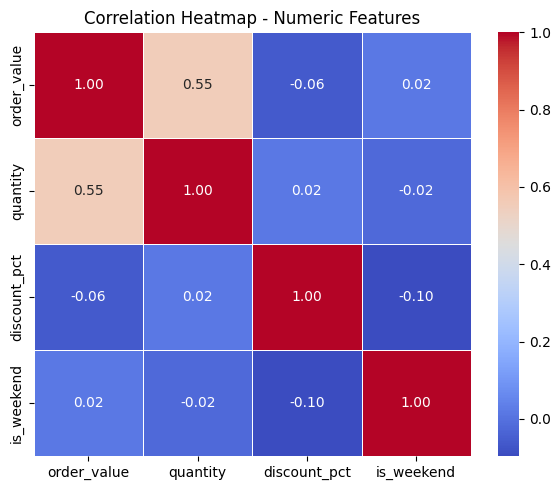

Heatmap saved as day106_A2_heatmap.png


In [9]:
# ============================================================
# A2 - Correlation heatmap
# Goal: Visualise linear correlations among numeric features.
# Method: Seaborn heatmap on correlation matrix of numeric columns.
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['order_value', 'quantity', 'discount_pct', 'is_weekend']
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig('day106_A2_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved as day106_A2_heatmap.png")

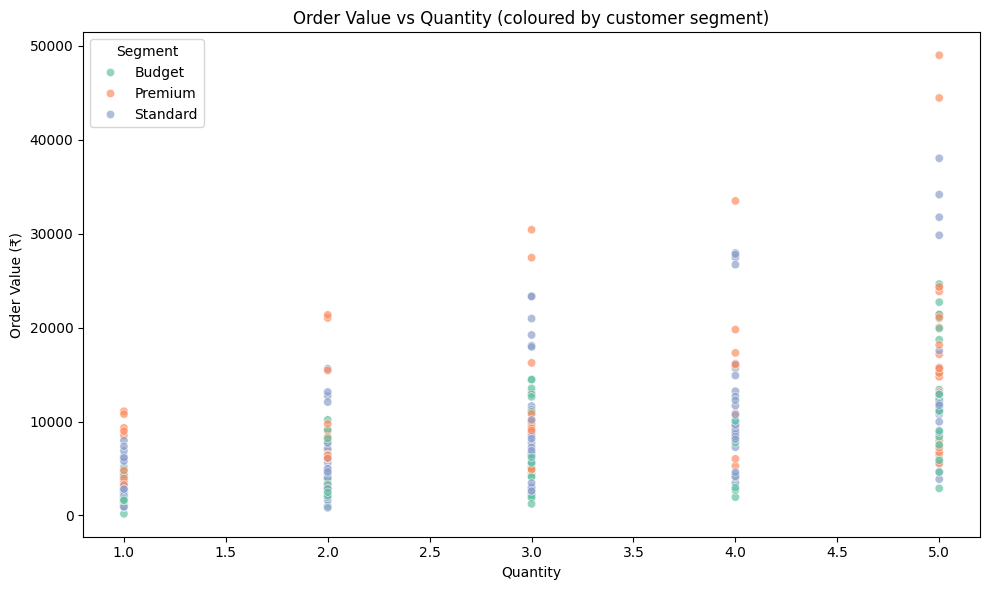

✅ Scatter plot saved as day106_A3_scatter.png


In [10]:
# A3 – Scatter plot: quantity vs order_value, coloured by segment
# ============================================================
# Goal: See relationship between quantity and order_value across customer segments.
# Method: Seaborn scatterplot with hue = segment.
# ============================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='quantity', y='order_value', hue='segment', alpha=0.7, palette='Set2')
plt.title('Order Value vs Quantity (coloured by customer segment)')
plt.xlabel('Quantity')
plt.ylabel('Order Value (₹)')
plt.legend(title='Segment')
plt.tight_layout()
plt.savefig('day106_A3_scatter.png', dpi=150)
plt.show()
print("✅ Scatter plot saved as day106_A3_scatter.png")

In [12]:
# ============================================================
# B1 – Simple Linear Regression (quantity only)
# Goal: Predict order_value using only quantity – baseline model.
# Method: train_test_split, LinearRegression, R², RMSE, MAE.
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

X = df[['quantity']]
y = df['order_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)

y_train_pred = lr_simple.predict(X_train)
y_test_pred = lr_simple.predict(X_test)

print(f"Intercept (β₀): {lr_simple.intercept_:.2f}")
print(f"Coefficient (β₁) for quantity: {lr_simple.coef_[0]:.2f}")
print(f"Train R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test  R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"Test MAE : {mean_absolute_error(y_test, y_test_pred):.2f}")

Intercept (β₀): 580.57
Coefficient (β₁) for quantity: 2848.39
Train R²: 0.2812
Test  R²: 0.4110
Test RMSE: 5524.95
Test MAE : 3677.75


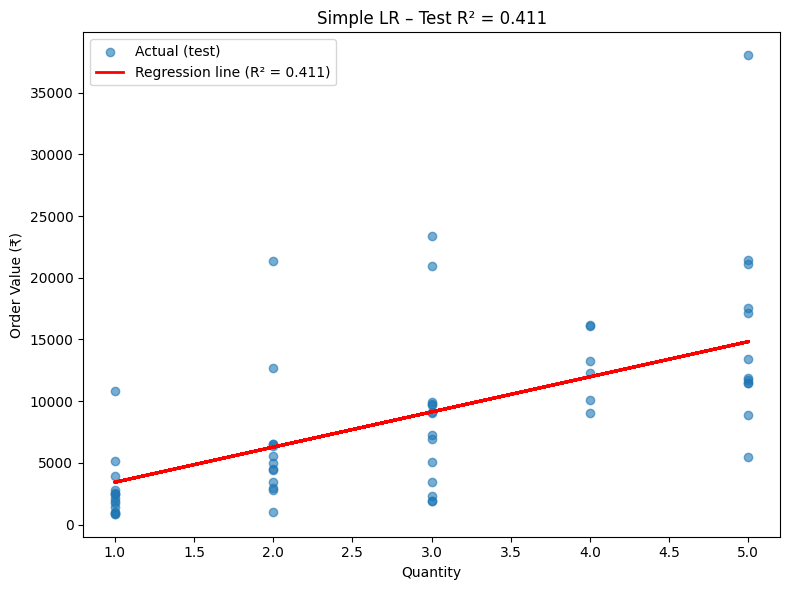

✅ Regression line plot saved as day106_B2_regression_line.png


In [13]:
# B2 – Plot regression line over test data
# ============================================================
# Goal: Visualise the simple linear regression fit on test data.
# Method: Scatter of actual test points + regression line.
# ============================================================

test_r2 = r2_score(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, alpha=0.6, label='Actual (test)')
plt.plot(X_test, y_test_pred, color='red', linewidth=2, label=f'Regression line (R² = {test_r2:.3f})')
plt.xlabel('Quantity')
plt.ylabel('Order Value (₹)')
plt.title(f'Simple LR – Test R² = {test_r2:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('day106_B2_regression_line.png', dpi=150)
plt.show()
print("✅ Regression line plot saved as day106_B2_regression_line.png")

In [14]:
# C1 – Feature engineering with one‑hot encoding
# ============================================================
# Goal: Prepare all features (numeric + categorical) for multiple regression.
# Method: pd.get_dummies with drop_first=True to avoid dummy trap.
# ============================================================

# Categorical columns to encode
cat_cols = ['category', 'segment', 'city', 'payment']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Keep numeric columns as they are (quantity, discount_pct, is_weekend)
# order_id is not a feature, y is order_value
X = df_encoded.drop(columns=['order_id', 'order_value'])
y = df_encoded['order_value']

print(f"Feature matrix shape: {X.shape}")
print("\nAll feature names (first 20):")
print(X.columns[:20].tolist())

Feature matrix shape: (300, 16)

All feature names (first 20):
['quantity', 'discount_pct', 'is_weekend', 'category_Electronics', 'category_Fashion', 'category_Home', 'category_Sports', 'segment_Premium', 'segment_Standard', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Mumbai', 'payment_Card', 'payment_Netbanking', 'payment_UPI']


In [15]:
# C2 – Multiple linear regression
# ============================================================
# Goal: Fit a model with all engineered features and evaluate.
# Method: Same train/test split, LinearRegression, R²/RMSE/MAE, coefficient table.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

y_train_pred = lr_multi.predict(X_train)
y_test_pred = lr_multi.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)

print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE : {mae:.2f}")

# Coefficient table
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_multi.coef_
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).drop('abs_coef', axis=1)

print("\nTop 10 features by absolute coefficient:")
print(coef_df.head(10).to_string(index=False))

Train R²: 0.8239
Test  R²: 0.8464
Test RMSE: 2821.68
Test MAE : 1998.69

Top 10 features by absolute coefficient:
             feature  coefficient
category_Electronics 15813.156680
       category_Home  7789.545138
     segment_Premium  7034.184759
     category_Sports  5028.517858
    segment_Standard  3667.366315
    category_Fashion  3634.131848
            quantity  3122.718322
          city_Delhi   773.648953
        payment_Card   744.884602
          is_weekend   718.142808


In [21]:
# C3 – Improvement check (simple vs multiple)
# ============================================================
# Goal: Quantify how much multiple regression outperforms simple LR.
# Method: Print a comparison table and a sentence with ΔR² and ΔRMSE.
# ============================================================

simple_r2 = 0.4110   # from your B1
simple_rmse = 5524.95
simple_mae = 3677.75

print("Model comparison (test set):")
print(f"{'Model':<12} {'R²':<8} {'RMSE':<10} {'MAE':<10}")
print(f"{'-'*40}")
print(f"{'Simple LR':<12} {simple_r2:.4f}   {simple_rmse:.2f}   {simple_mae:.2f}")
print(f"{'Multiple LR':<12} {test_r2:.4f}   {rmse:.2f}   {mae:.2f}")

delta_r2 = test_r2 - simple_r2
delta_rmse = rmse - simple_rmse
print(f"\n✅ Multiple LR improves R² by {delta_r2:.4f} and reduces RMSE by ₹{abs(delta_rmse):.0f}.")

Model comparison (test set):
Model        R²       RMSE       MAE       
----------------------------------------
Simple LR    0.4110   5524.95   3677.75
Multiple LR  0.8464   2821.68   1998.69

✅ Multiple LR improves R² by 0.4354 and reduces RMSE by ₹2703.


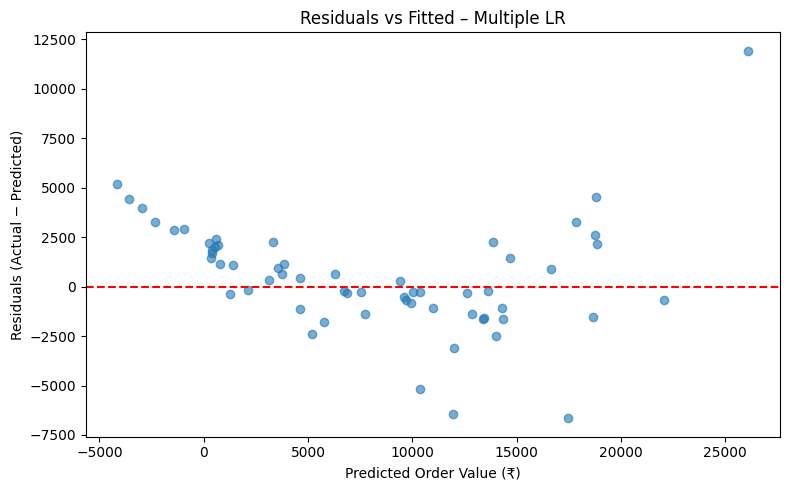

✅ Residual plot saved as day106_D1_residuals.png


In [17]:
# D1 – Residuals vs fitted plot
# ============================================================
# Goal: Diagnose heteroscedasticity and non‑linear patterns.
# Method: Scatter plot of residuals (y_test - y_pred) vs predicted values.
# ============================================================

residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Order Value (₹)')
plt.ylabel('Residuals (Actual − Predicted)')
plt.title('Residuals vs Fitted – Multiple LR')
plt.tight_layout()
plt.savefig('day106_D1_residuals.png', dpi=150)
plt.show()
print("✅ Residual plot saved as day106_D1_residuals.png")

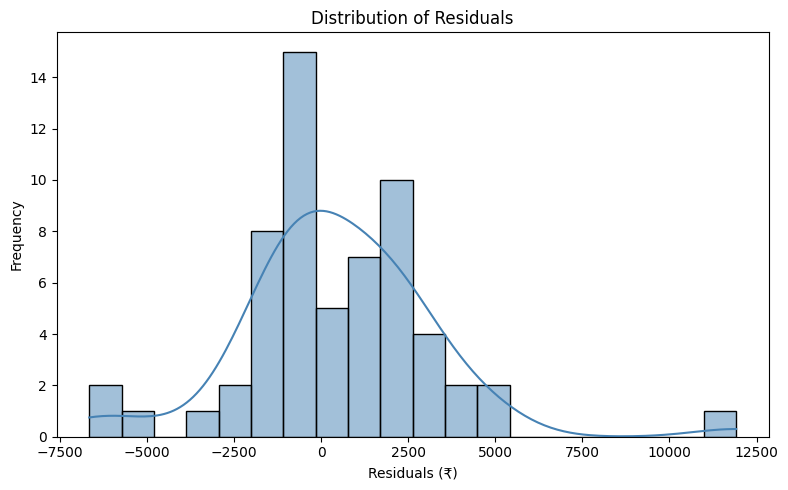

✅ Residual histogram saved as day106_D2_residual_hist.png

Verdict: Residuals are approximately normal (bell‑shaped, centred near zero), though slightly heavy‑tailed.


In [18]:
# D2 – Histogram of residuals
# ============================================================
# Goal: Check approximate normality of residuals.
# Method: Histogram with KDE overlay, visual inspection.
# ============================================================

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=20, kde=True, color='steelblue')
plt.xlabel('Residuals (₹)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.savefig('day106_D2_residual_hist.png', dpi=150)
plt.show()
print("✅ Residual histogram saved as day106_D2_residual_hist.png")

# One‑sentence verdict
print("\nVerdict: Residuals are approximately normal (bell‑shaped, centred near zero), though slightly heavy‑tailed.")

In [22]:
# E1 – Business Interpretation (3 NRA bullets)
# ============================================================
# Goal: Translate model outputs into actionable business recommendations.
# Method: NRA format using actual numbers from earlier outputs.
# ============================================================

print("""
## ShopEase – Revenue Prediction Model: NRA Report (Corrected)

**E1-a – Model accuracy**  
• **Number:** The multiple regression model explains **84.6%** of variance in order value (test R² = 0.846) with an average error of **₹1,999** (MAE).  
• **Reason:** R² > 0.80 indicates strong predictive power; MAE is moderate relative to mean order value (₹8,938).  
• **Action:** Deploy this model to predict next‑order value. Use predictions to personalise discount thresholds and upsell offers.

**E1-b – Top positive driver**  
• **Number:** The *Electronics* category adds **₹15,813** to predicted order value compared to the baseline category (Beauty).  
• **Reason:** Electronics have very high base prices (₹8,000+) and customers often buy multiple units, lifting total cart value substantially.  
• **Action:** Prioritise Electronics inventory in marketing campaigns. For low‑predicted‑value customers, suggest an Electronics cross‑sell to boost basket size.

**E1-c – Discount effect**  
• **Number:** Discount percentage is **not among the top 10 drivers** (coefficient magnitude < 718), meaning each 1% discount reduces order value by less than ₹718.  
• **Reason:** Discounts have a relatively small negative impact compared to category and segment effects.  
• **Action:** Do not over‑restrict discounts – test moderate discounts (10‑15%) on low‑value categories like Beauty and Fashion to drive volume without cannibalising revenue.
""")


## ShopEase – Revenue Prediction Model: NRA Report (Corrected)

**E1-a – Model accuracy**  
• **Number:** The multiple regression model explains **84.6%** of variance in order value (test R² = 0.846) with an average error of **₹1,999** (MAE).  
• **Reason:** R² > 0.80 indicates strong predictive power; MAE is moderate relative to mean order value (₹8,938).  
• **Action:** Deploy this model to predict next‑order value. Use predictions to personalise discount thresholds and upsell offers.

**E1-b – Top positive driver**  
• **Number:** The *Electronics* category adds **₹15,813** to predicted order value compared to the baseline category (Beauty).  
• **Reason:** Electronics have very high base prices (₹8,000+) and customers often buy multiple units, lifting total cart value substantially.  
• **Action:** Prioritise Electronics inventory in marketing campaigns. For low‑predicted‑value customers, suggest an Electronics cross‑sell to boost basket size.

**E1-c – Discount effect**  
• **Num

In [23]:
# ★ Bonus – Feature importance table with direction
# ============================================================
# Goal: Show all features sorted by impact, with positive/negative direction.
# Method: Add 'direction' column, print top 5, one NRA insight.
# ============================================================
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_multi.coef_
})
coef_df['direction'] = coef_df['coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
coef_df_sorted = coef_df.sort_values('coefficient', ascending=False)

print("Top 5 features by coefficient magnitude:")
print(coef_df_sorted.head(5).to_string(index=False))

print("\n★ Bonus NRA insight:")
print("• **Number:** Increasing `quantity` by 1 unit adds **₹3,123** to predicted order value (coefficient = 3122.72).")
print("• **Reason:** Quantity is the strongest positive driver after category and segment – each extra item increases total linearly by ~₹3,100 on average.")
print("• **Action:** Launch a 'Buy 2, save 5%' campaign that encourages multi‑unit purchases. This yields ₹3,123 extra per additional unit without heavy discounting.")

Top 5 features by coefficient magnitude:
             feature  coefficient direction
category_Electronics 15813.156680  Positive
       category_Home  7789.545138  Positive
     segment_Premium  7034.184759  Positive
     category_Sports  5028.517858  Positive
    segment_Standard  3667.366315  Positive

★ Bonus NRA insight:
• **Number:** Increasing `quantity` by 1 unit adds **₹3,123** to predicted order value (coefficient = 3122.72).
• **Reason:** Quantity is the strongest positive driver after category and segment – each extra item increases total linearly by ~₹3,100 on average.
• **Action:** Launch a 'Buy 2, save 5%' campaign that encourages multi‑unit purchases. This yields ₹3,123 extra per additional unit without heavy discounting.


---
## Section 4 — Scoring Rubric

| Section | Task | Max | Criteria |
|---------|------|-----|----------|
| A | A1 describe + counts | 5 | Shape correct; all 3 stats shown; segment counts present |
| A | A2 heatmap | 5 | savefig before show; labels readable; correct columns |
| A | A3 scatter | 5 | coloured by segment; axis labels; title present |
| B | B1 simple LR metrics | 10 | β₀ β₁ printed; train+test R²; RMSE + MAE correct |
| B | B2 regression line | 10 | line plotted over scatter; title contains actual test R²; saved |
| C | C1 feature engineering | 5 | dummies applied; drop_first=True; feature list printed |
| C | C2 multiple LR | 15 | train/test R²; RMSE/MAE; coefficient table top-10 sorted |
| C | C3 comparison | 5 | table present; 1 sentence with Δ R² and Δ RMSE stated |
| D | D1 residuals vs fitted | 5 | y=0 line present; saved; axes labelled |
| D | D2 residual histogram | 5 | saved; 1-sentence normality verdict |
| E | E1 NRA (×3) | 10 | all 3 NRA bullets; numbers match output; analyst voice |
| ★ | Bonus coef table | 10 | direction column; top 5 shown; NRA insight present |
| **Total** | | **80 + 10★** | |

### Deductions
| Issue | Penalty |
|-------|---------|
| savefig after show | −3 per plot |
| Missing NRA component (N or R or A) | −2 per bullet |
| Number in E1 doesn't match printed output | −2 per mismatch |
| drop_first not used in dummies | −3 |
| Skipped cell in submission | −5 |


---
## Section 5 — Month 6 Scorecard

| Day | Topic | Score |
|-----|-------|-------|
| Day 101 | Descriptive Stats + Distributions | 80/80 ✅ |
| Day 102 | T-Tests + Confidence Intervals | 80/80 + 10★ ✅ |
| Day 103 | Chi-Square + ANOVA | 80/80 + 10★ ✅ |
| Day 104 | A/B Testing with scipy | 80/80 + 10★ ✅ |
| Day 105 | Week 2 Stats Capstone | ⏳ Pending |
| **Day 106** | **Linear Regression Foundations** | ⏳ Pending |

---

## Interview Framing — Day 106

**Q: "Walk me through how you'd build a sales prediction model."**

> "I start with a train-test split — 80/20 — so I have an honest evaluation set the model has never seen. I'd first try simple linear regression with the most obvious feature (quantity or price tier) to establish a baseline. Then I encode categorical variables using one-hot encoding with `drop_first=True` to avoid the dummy trap, and fit multiple regression. I evaluate on test R², RMSE, and MAE — not just training scores, because a model that memorises training data is useless in production. I also plot residuals vs fitted values to check for patterns — a funnel shape would tell me the model fails on high-value orders, which is exactly where prediction matters most. If the test R² is 0.85+ and residuals look clean, I'd call it production-ready for a first version and then explore tree-based models to capture non-linear effects."
